In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

You'll want to tweak these parameters to match the values you have setup in your ensemble. 

In [14]:
max_steps = 80000
step_size = 10000
ts = [x * step_size for x in range(1, int(max_steps / step_size) + 1)]


In [15]:
df_1st = pd.read_csv("Output/Testing_03/Testing_01chain_outputs_10000.csv")
df_2nd = pd.read_csv("Output/Testing_04/Testing_01chain_outputs_10000.csv")
for t in ts[1:]: 

    df2 = pd.read_csv(f"Output/Testing_03/Testing_01chain_outputs_{t}.csv")
    df_1st = pd.concat([df_1st,df2],ignore_index=True)

for t in ts[1:]:
    df_2nd_2 = pd.read_csv(f"Output/Testing_04/Testing_01chain_outputs_{t}.csv")
    df_2nd = pd.concat([df_2nd,df_2nd_2],ignore_index=True)

dfs = [df_1st, df_2nd]

In [16]:
df_1st

,Unnamed: 0,CountySplits,MM,EG,PB,DWins,PP,Comp45-55
0,0,6,-0.004476,0.157689,-0.166667,9,28.226527,1
1,1,6,-0.004214,0.157689,-0.166667,9,28.206479,1
2,2,6,-0.004220,0.157689,-0.166667,9,28.415428,1
3,3,7,-0.004178,0.157689,-0.166667,9,28.922890,1
4,4,7,-0.012489,0.157689,-0.166667,9,28.462400,1
...,...,...,...,...,...,...,...,...
79994,9995,7,-0.000596,0.157689,-0.055556,9,22.738653,1
79995,9996,7,-0.000596,0.157689,-0.055556,9,22.738653,1
79996,9997,7,-0.000676,0.157689,-0.055556,9,22.553217,1
79997,9998,7,-0.000737,0.157689,-0.055556,9,22.675091,1


In [17]:
df_2nd

,Unnamed: 0,CountySplits,MM,EG,PB,DWins,PP,Comp45-55
0,0,6,-0.012468,0.157689,-0.055556,9,24.922141,1
1,1,6,-0.011907,0.157689,-0.055556,9,27.071213,1
2,2,6,-0.011809,0.157689,-0.055556,9,27.347244,1
3,3,6,-0.022714,0.157689,-0.166667,9,25.702773,1
4,4,6,-0.012426,0.157689,-0.055556,9,28.220109,1
...,...,...,...,...,...,...,...,...
79994,9995,6,-0.004846,0.157689,-0.055556,9,24.681707,1
79995,9996,6,-0.004846,0.157689,-0.055556,9,24.681707,1
79996,9997,6,-0.004928,0.157689,-0.055556,9,24.540339,1
79997,9998,6,-0.004959,0.157689,-0.055556,9,24.436660,1


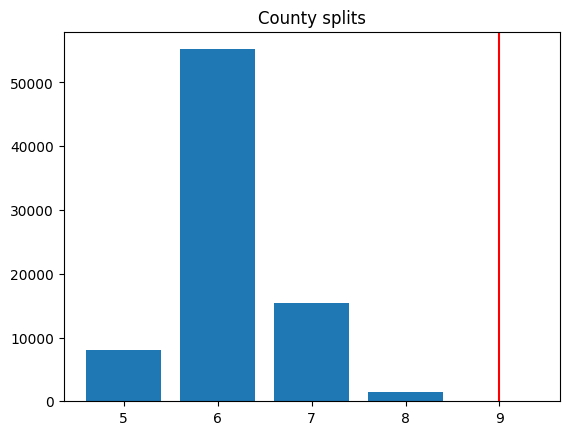

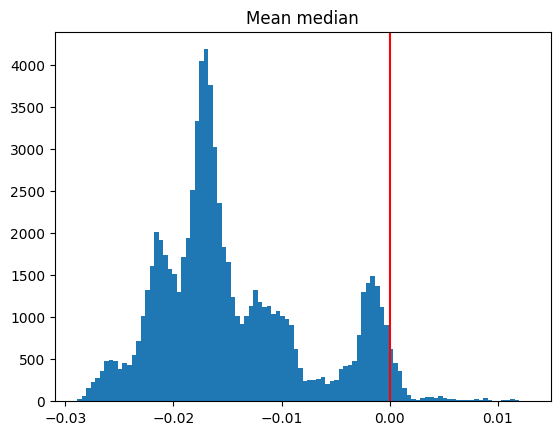

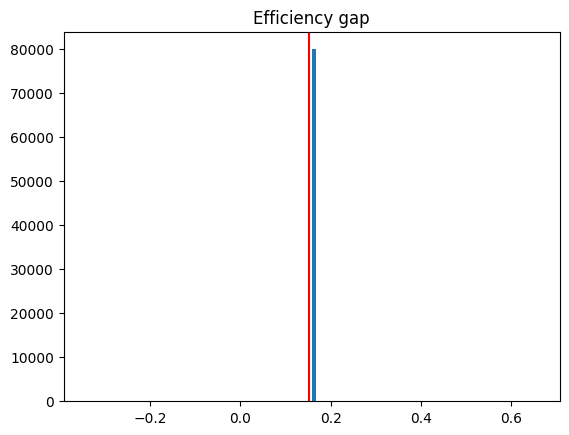

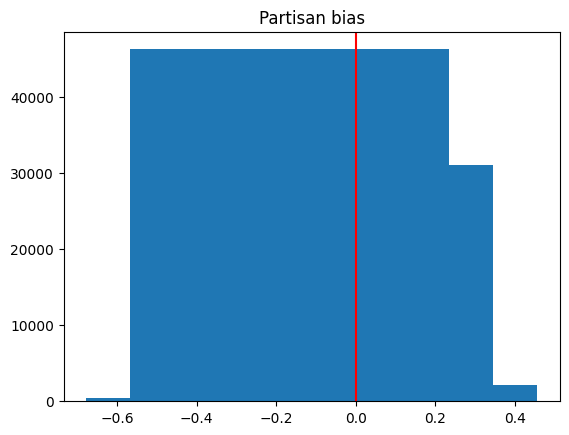

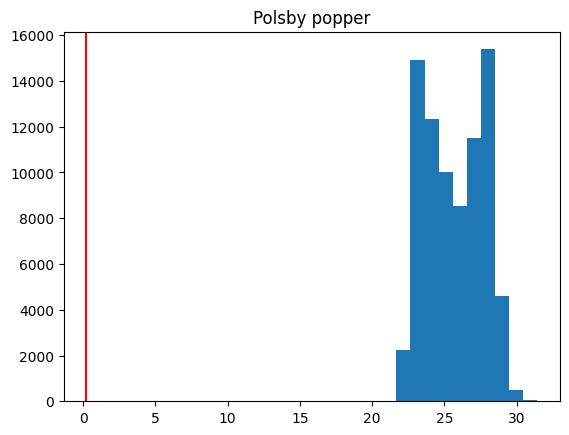

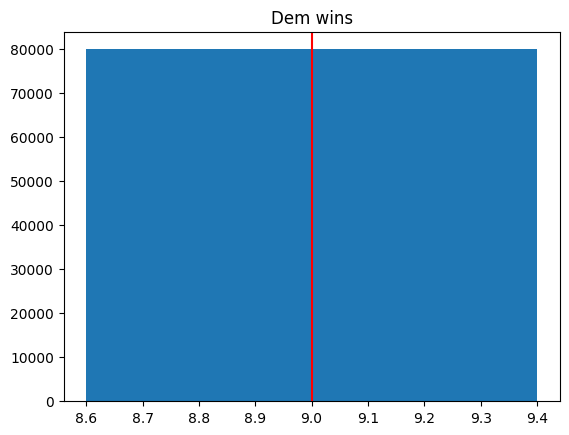

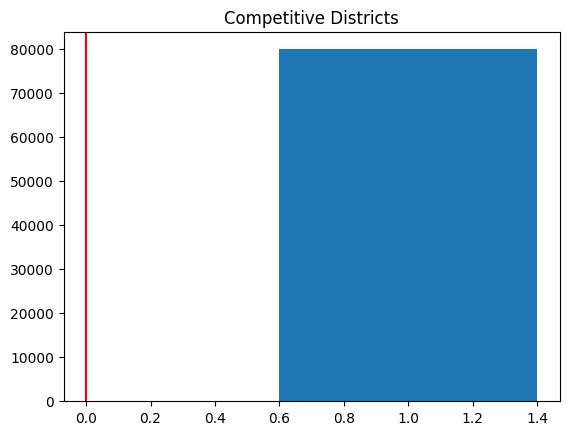

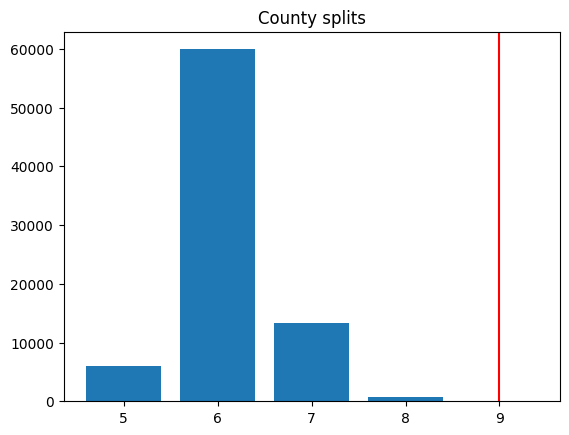

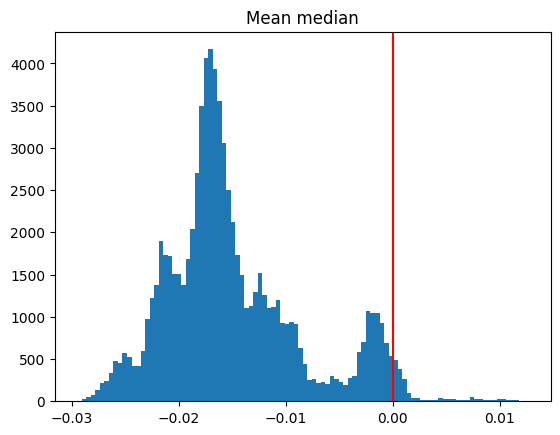

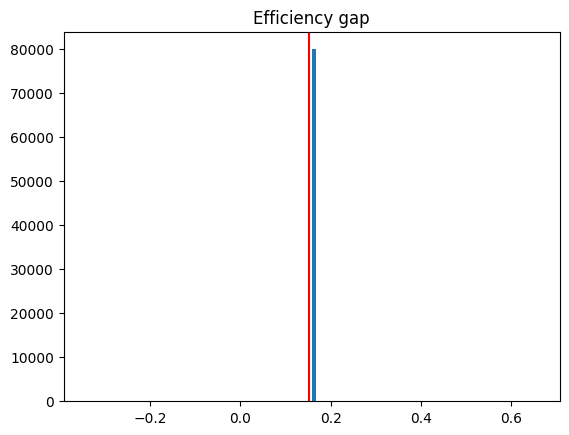

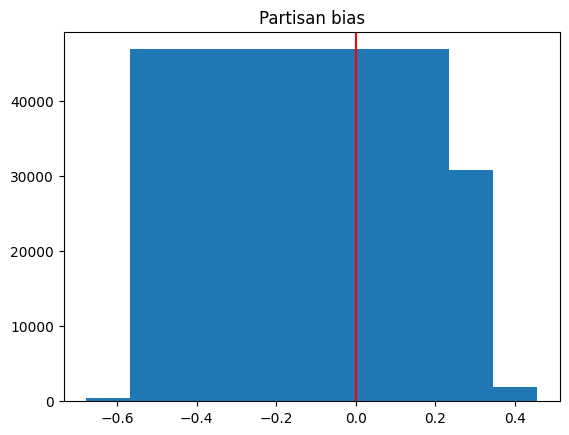

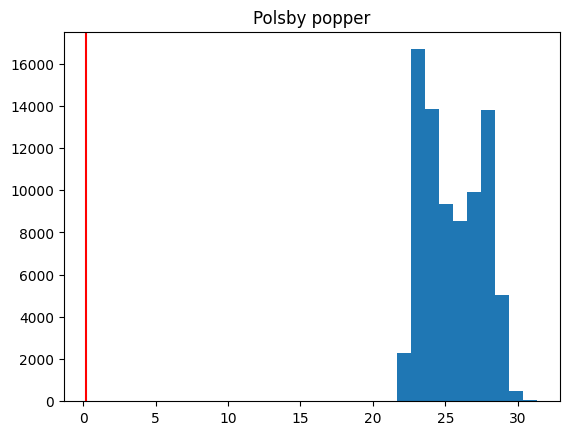

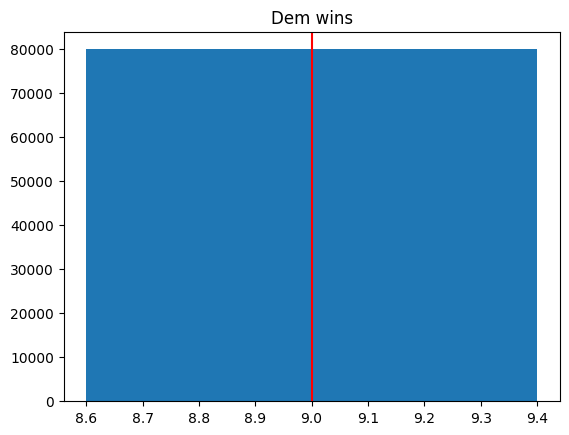

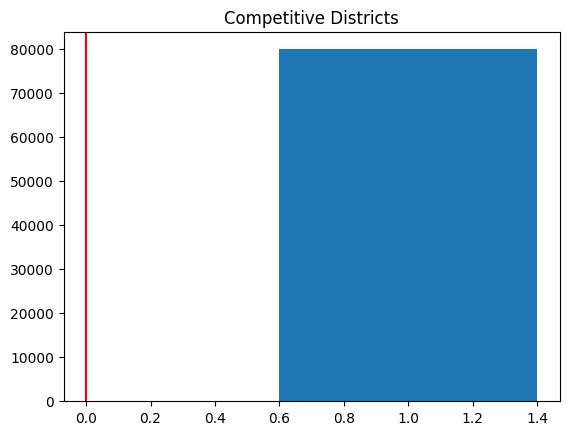

In [19]:
for df in dfs:
    counts = Counter(df['CountySplits'])
    categories = list(counts.keys())
    frequencies = list(counts.values())
    plt.bar(categories, frequencies)
    plt.axvline(9, color='red',label='Enacted')
    plt.title("County splits")
    plt.show()

    plt.hist(df['MM'],bins=100)
    plt.axvline(0, color='red',label='Enacted')
    plt.title("Mean median")
    plt.show()

    plt.hist(df['EG'],bins=100)
    plt.axvline(0.152, color='red',label='Enacted')
    plt.title("Efficiency gap")
    plt.show()

    #plt.hist(df['PB'])

    counts = Counter(df['PB'])
    categories = list(counts.keys())
    frequencies = list(counts.values())
    plt.bar(categories, frequencies)
    plt.axvline(0, color='red',label='Enacted')
    plt.title("Partisan bias")
    plt.show()


    plt.hist(df['PP'])
    plt.axvline(0.223, color='red',label='Enacted')
    plt.title("Polsby popper")
    plt.show()

    counts = Counter(df['DWins'])

    categories = list(counts.keys())
    frequencies = list(counts.values())

    plt.bar(categories, frequencies)
    plt.axvline(9, color='red',label='Enacted')
    plt.title("Dem wins")
    plt.show()


    counts = Counter(df['Comp45-55'])

    categories = list(counts.keys())
    frequencies = list(counts.values())

    plt.bar(categories, frequencies)
    plt.axvline(0, color='red',label='Enacted')
    plt.title("Competitive Districts")
    plt.show()

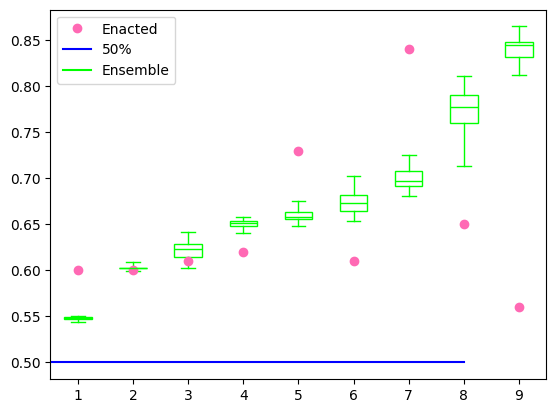

In [21]:
a = []
for t in ts:
    tempvotes = np.loadtxt(f"Output/Testing_03/Testing_01_DemPercs_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s, :])

a = np.array(a)

c='lime'

medianprops = dict(color="black")

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
# ax1.add_patch(patches.Rectangle((0, .37), 35, .18,color='honeydew'))
# plt.plot([0,34], [.55, .55], 'lightgreen')
# plt.plot([0,34], [.37, .37], 'lightgreen')
plt.boxplot(
    a,
    whis=[1, 99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c, markeredgecolor=c),
    medianprops=dict(color=c),
)

plt.plot(range(1, 10), [0.60, 0.60, 0.61, 0.62,
                       0.73, 0.61, 0.84, 0.65, 0.56], "o", color="hotpink", label="Enacted")

#plt.plot([0.5, 8], [0.4, 0.4], color="yellow", label="40%")
plt.plot([0.5, 8], [0.5, 0.5], color="blue", label="50%")
plt.plot([],[],color='lime',label='Ensemble')
plt.legend()
#plt.ylim([0, 0.7])



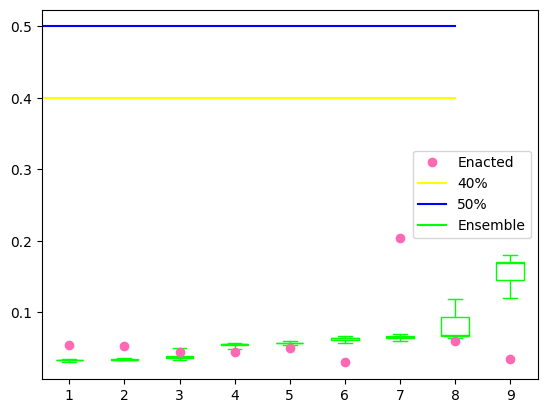

In [22]:
a = []
for t in ts:
    tempvotes = np.loadtxt(f"Output/Testing_03/Testing_01_BlackPercs_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s, :])

a = np.array(a)

c='lime'

medianprops = dict(color="black")

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
# ax1.add_patch(patches.Rectangle((0, .37), 35, .18,color='honeydew'))
# plt.plot([0,34], [.55, .55], 'lightgreen')
# plt.plot([0,34], [.37, .37], 'lightgreen')
plt.boxplot(
    a,
    whis=[1, 99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c, markeredgecolor=c),
    medianprops=dict(color=c),
)

plt.plot(range(1, 10), [0.055,
 0.053,
 0.045,
 0.045,
 0.05,
 0.03,
 0.204, 0.06, 0.035], "o", color="hotpink", label="Enacted")

plt.plot([0.5, 8], [0.4, 0.4], color="yellow", label="40%")
plt.plot([0.5, 8], [0.5, 0.5], color="blue", label="50%")
plt.plot([],[],color='lime',label='Ensemble')
plt.legend()
#plt.ylim([0, 0.7])

